In [1]:
# ===== LIBRERÍAS =====
import time
import os
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import StratifiedKFold, train_test_split
from ucimlrepo import fetch_ucirepo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# ===== CAPA LEGENDRE =====
class PolynomialLegendre(tf.keras.layers.Layer):
    def __init__(self, units, degree=2, use_bias=True, **kwargs):
        super(PolynomialLegendre, self).__init__(**kwargs)
        self.units = units
        self.degree = degree
        self.use_bias = use_bias

    def build(self, input_shape):
        input_dim_leg = input_shape[-1]

        self.kernel_leg = self.add_weight(
            shape=(input_dim_leg * self.degree, self.units),
            initializer=tf.keras.initializers.GlorotUniform(),
            trainable=True,
            name="kernel_leg"
        )

        if self.use_bias:
            self.bias_leg = self.add_weight(
                shape=(self.units,),
                initializer="zeros",
                trainable=True,
                name="bias_leg"
            )

    def call(self, inputs):
        # Convertimos la entrada al tipo de dato activo de la capa
        input_values = tf.cast(inputs, self.compute_dtype)

        # Valores iniciales de la recurrencia:
        # P0(x) = 1
        previous_previous_poly = tf.ones_like(input_values)

        # P1(x) = x
        previous_poly = input_values

        # Empezamos guardando el primer polinomio
        legendre_features = [previous_poly]

        # Generamos el resto de grados usando la recurrencia de Legendre
        for degree_index in range(2, self.degree + 1):
            current_degree = tf.cast(degree_index, self.compute_dtype)

            #Esto es el polinomio de Legendre pero calculado con la Recurrencia de Bonnet
            current_poly = ((2.0 * current_degree - 1.0) * input_values * previous_poly - (current_degree - 1.0) * previous_previous_poly) / current_degree

            legendre_features.append(current_poly)

            # SIguientes iteraciones
            previous_previous_poly = previous_poly
            previous_poly = current_poly

        # Unimos todas las bases polinómicas en un solo vector
        polynomial_basis = tf.concat(legendre_features, axis=-1)

        # Proyección lineal final, equivalente a una capa densa
        output_values = tf.matmul(polynomial_basis, self.kernel_leg)

        if self.use_bias:
            output_values = tf.nn.bias_add(output_values, self.bias_leg)

        return output_values


In [3]:
# ===== PLOT =====
def plot_cv_average_history_leg(histories_leg):
    max_epochs_leg = max([len(h.history['loss']) for h in histories_leg])
    epochs_leg = np.arange(1, max_epochs_leg + 1)

    def get_padded_metrics_leg(metric_name):
        matrix_leg = np.full((len(histories_leg), max_epochs_leg), np.nan)
        for i, h in enumerate(histories_leg):
            data_leg = h.history[metric_name]
            matrix_leg[i, :len(data_leg)] = data_leg
        return np.nanmean(matrix_leg, axis=0)

    avg_loss_leg = get_padded_metrics_leg('loss')
    avg_val_loss_leg = get_padded_metrics_leg('val_loss')
    avg_acc_leg = get_padded_metrics_leg('accuracy')
    avg_val_acc_leg = get_padded_metrics_leg('val_accuracy')

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_leg, avg_loss_leg)
    plt.plot(epochs_leg, avg_val_loss_leg)
    plt.title('Pérdida Promedio')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_leg, avg_acc_leg)
    plt.plot(epochs_leg, avg_val_acc_leg)
    plt.title('Precisión Promedio')

    plt.tight_layout()
    plt.show()


In [4]:
def PolynomialDenseCreator_leg(degree, input_dim, num_classes):
    inputs = keras.Input(shape=(input_dim,))

    x = PolynomialLegendre(32, degree=degree)(inputs)
    x = layers.Activation('swish')(x)
    x = layers.Dense(16, activation='relu')(x)

    output = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, output)

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [5]:
# ===== DATOS =====
idDataset = 109  # 159 = MAGIC, 53 = IRIS
magic_gamma_telescope_leg = fetch_ucirepo(id=idDataset)

X = magic_gamma_telescope_leg.data.features.to_numpy()
y = magic_gamma_telescope_leg.data.targets.to_numpy()


In [6]:
# ===== HIPERPARÁMETROS =====
epochs = 400
batch_size = 32
num_splits = 10
degrees = [2, 3, 4, 5, 6]

In [7]:
def createEarlyStoppingCallback_leg(patience_leg=15):
    return keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=patience_leg,
        restore_best_weights=True
    )

In [8]:
# ===== CROSS VALIDATION =====
skf = StratifiedKFold(n_splits=num_splits, shuffle=True, random_state=1)

history = {deg: [] for deg in degrees}
scores = {deg: [] for deg in degrees}
times = {deg: [] for deg in degrees}

for train_idx, test_idx in skf.split(X, y):

    # Split
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Encoding
    le = LabelEncoder()
    y_train = le.fit_transform(y_train.ravel())
    y_test = le.transform(y_test.ravel())

    # Validación interna
    X_sub, X_val, y_sub, y_val = train_test_split(
        X_train, y_train,
        test_size=0.3,
        stratify=y_train,
        random_state=42
    )

    # Normalización
    scaler = MinMaxScaler(feature_range=(-1, 1))
    X_sub = scaler.fit_transform(X_sub)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    num_classes = len(np.unique(y_train))
    input_dim = X_sub.shape[1]

    for deg in degrees:
        tf.keras.backend.clear_session()

        model = PolynomialDenseCreator_leg(deg, input_dim, num_classes)

        start = time.time()

        hist = model.fit(
            X_sub, y_sub,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            verbose=0,
        )

        end = time.time()

        result = model.evaluate(X_test, y_test, verbose=0)

        history[deg].append(hist)
        scores[deg].append(result)
        times[deg].append(end - start)



  RESULTADOS FINALES (Promedio CV - Legendre)
Grado 2: Pérdida Promedio = 0.1014, Precisión Promedio = 0.9611, Tiempo Promedio = 26.7854


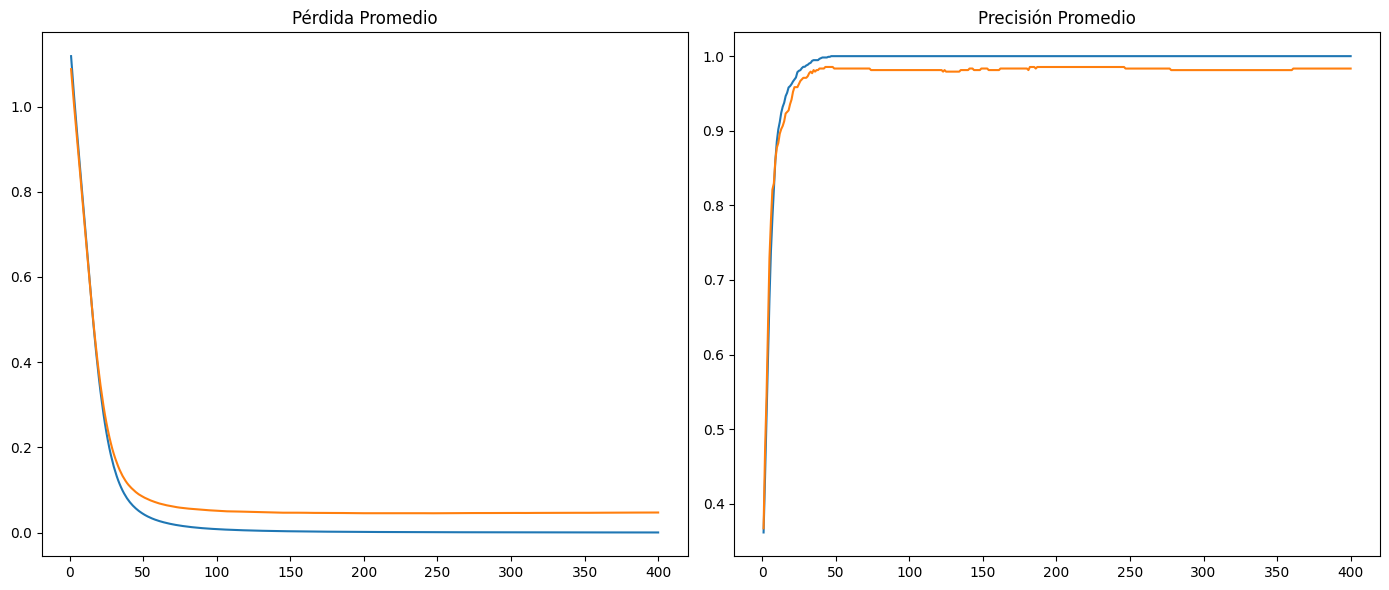

Grado 3: Pérdida Promedio = 0.1285, Precisión Promedio = 0.9663, Tiempo Promedio = 27.7377


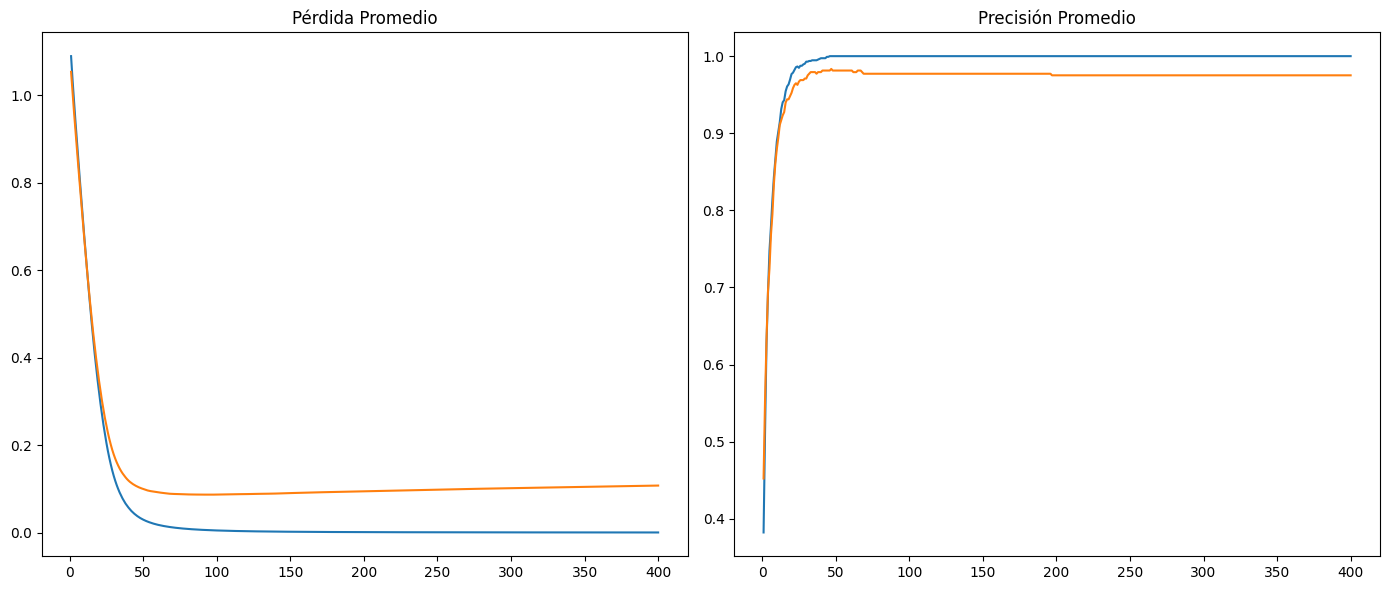

Grado 4: Pérdida Promedio = 0.0259, Precisión Promedio = 0.9889, Tiempo Promedio = 27.7704


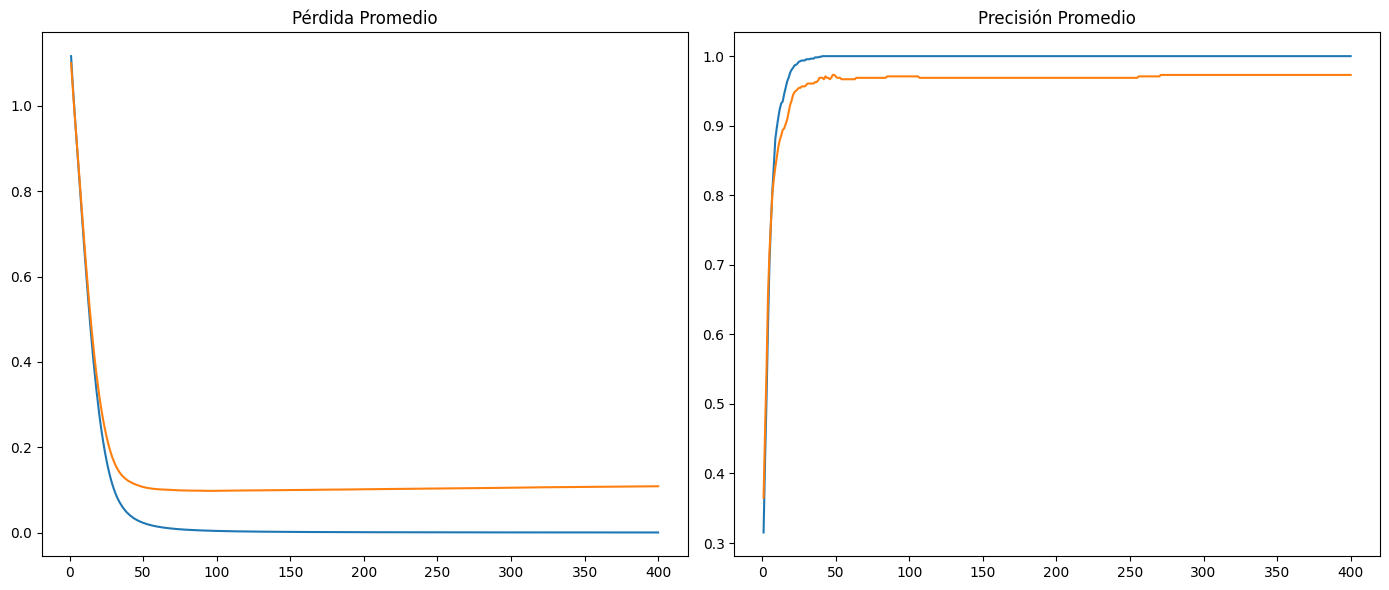

Grado 5: Pérdida Promedio = 0.4099, Precisión Promedio = 0.9608, Tiempo Promedio = 26.8220


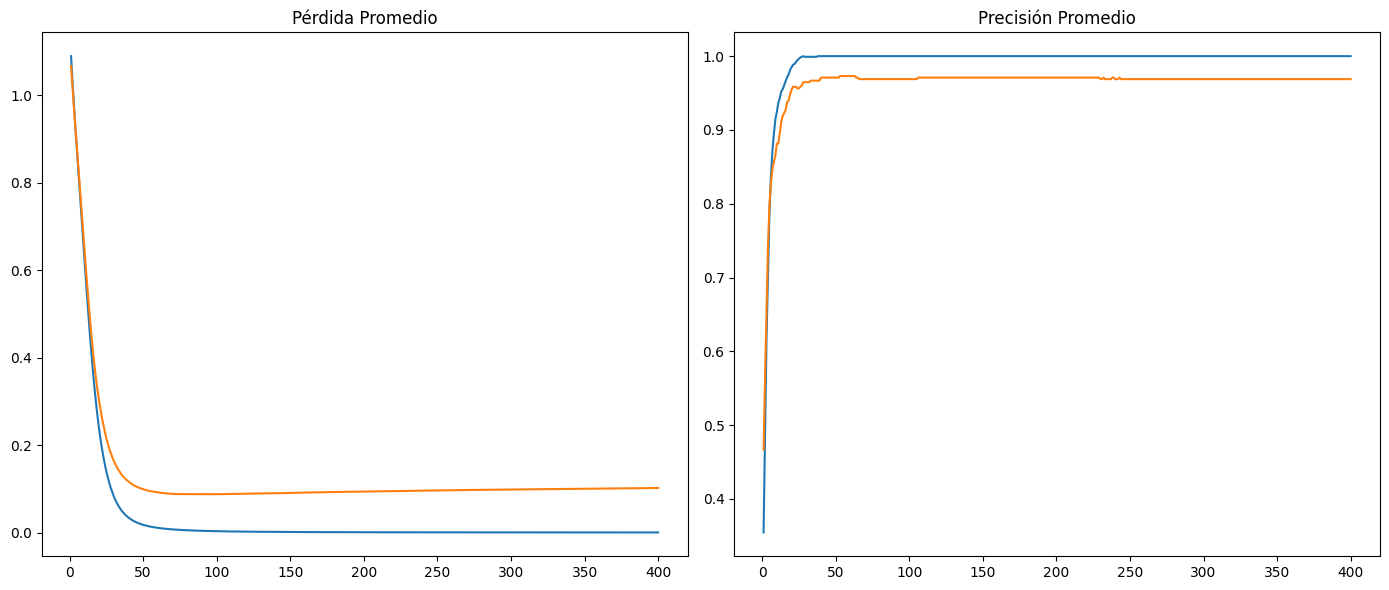

Grado 6: Pérdida Promedio = 1.8417, Precisión Promedio = 0.9327, Tiempo Promedio = 27.5574


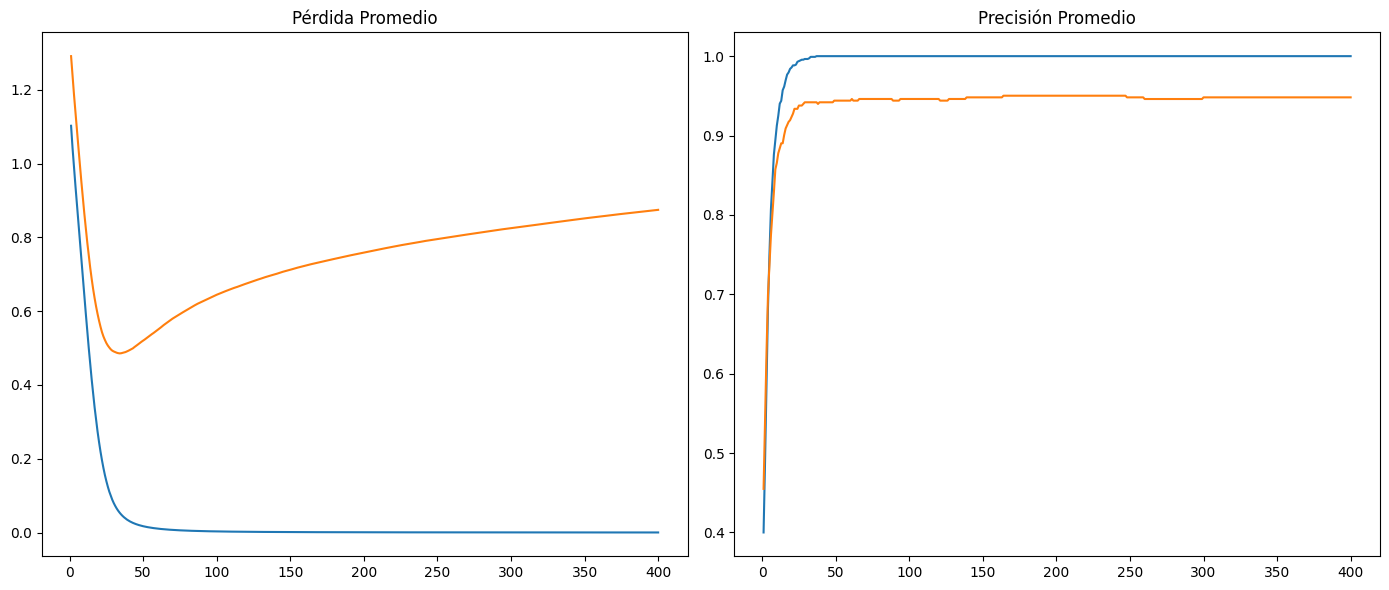

In [12]:
def calculator(scores, times):
    loss = np.mean([s[0] for s in scores])
    acc = np.mean([s[1] for s in scores])
    t = np.mean(times)
    return loss, acc, t


print("\n" + "="*40)
print("  RESULTADOS FINALES (Promedio CV - Legendre)")
print("="*40)

scoreMean_leg = {}
for deg in degrees:
    scoreMean_leg[deg] = calculator(scores[deg], times[deg])
    print(f"Grado {deg}: Pérdida Promedio = {scoreMean_leg[deg][0]:.4f}, Precisión Promedio = {scoreMean_leg[deg][1]:.4f}, Tiempo Promedio = {scoreMean_leg[deg][2]:.4f}")
    plot_cv_average_history_leg(history[deg])
